In [97]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [98]:
df=pd.read_csv("train_minst.csv")

In [99]:
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


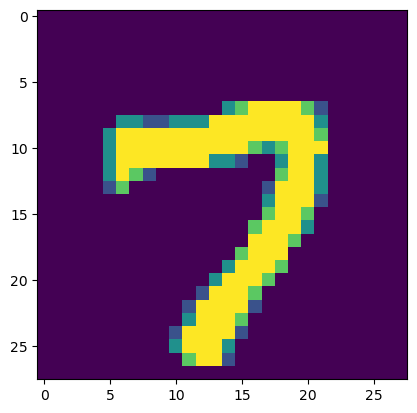

In [100]:
plt.imshow(df.iloc[41997,1:].values.reshape(28,28))

In [101]:
# first we will train the data without pca and will calculate the score

In [102]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [103]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [104]:
x_train.shape

(33600, 784)

In [105]:
from sklearn.neighbors import KNeighborsClassifier 
KNN= KNeighborsClassifier()
KNN.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [106]:
y_pred=KNN.predict(x_test)

In [107]:
from sklearn.metrics import accuracy_score
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.9680952380952381


In [108]:
# now we will apply pca and see the score
x=df.iloc[:,1:]
y=df.iloc[:,0]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [109]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
st.fit(x_train)
x_train=st.transform(x_train)
x_test=st.transform(x_test)

In [161]:
from sklearn.decomposition import PCA
pc=PCA(n_components=300)
# here we have have to pass that in how many dimensional we want this data
pc.fit(x_train)

,n_components,300
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [162]:
x_train_transform=pc.transform(x_train)
x_test_transform=pc.transform(x_test)

In [163]:
x_train_transform.shape

(33600, 300)

In [164]:
KNN= KNeighborsClassifier()
KNN.fit(x_train_transform,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [165]:
y_pred=KNN.predict(x_test_transform)

In [166]:
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.9458333333333333


In [116]:
# we can check for 784 but it take more times so we will see for 20 columns
for i in range(1,10):
    pc=PCA(n_components=i)
    pc.fit(x_train)
    x_train_transform=pc.transform(x_train)
    x_test_transform=pc.transform(x_test)
    KNN= KNeighborsClassifier()
    KNN.fit(x_train_transform,y_train)
    y_pred=KNN.predict(x_test_transform)
    print("accuracy",accuracy_score(y_test,y_pred))
    

accuracy 0.2636904761904762
accuracy 0.32285714285714284
accuracy 0.5114285714285715
accuracy 0.6685714285714286
accuracy 0.7410714285714286
accuracy 0.8264285714285714
accuracy 0.8408333333333333
accuracy 0.8714285714285714
accuracy 0.8877380952380952


In [117]:
# transforming to 2d cordinate system
pc=PCA(n_components=2)
x_train_trf=pc.fit_transform(x_train)
x_test_trf=pc.transform(x_test)
x_train_trf

array([[ 7.08555976,  2.60519753],
       [11.08323745,  2.20072402],
       [-2.34528886,  7.2080613 ],
       ...,
       [-5.04390493,  5.86144956],
       [11.75653493, -6.27600121],
       [-3.86602198,  4.80718722]], shape=(33600, 2))

In [118]:
import plotly.express as px

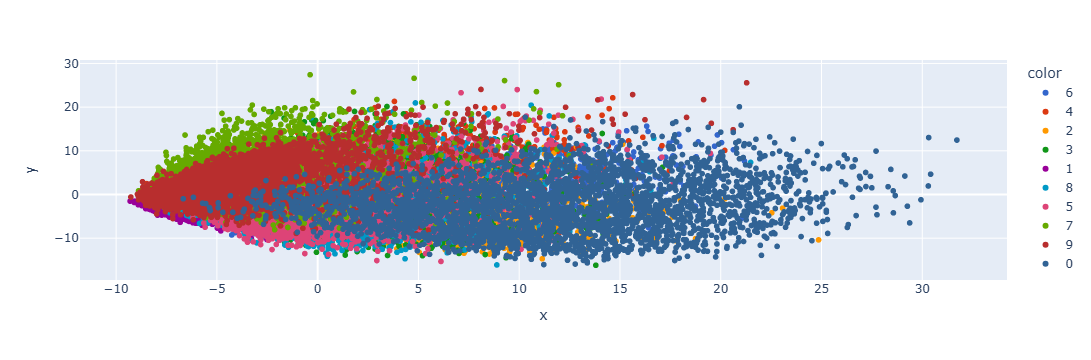

In [119]:
px.scatter(x=x_train_trf[:,0],y=x_train_trf[:,1],color=y_train.astype(str),color_discrete_sequence=px.colors.qualitative.G10)

In [120]:
#transforming to 3d cordinate

In [121]:
pc=PCA(n_components=3)
pc.fit(x_train)

,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [122]:
x_train_trf=pc.transform(x_train)
x_test_trf=pc.transform(x_test)

In [123]:
x_train_trf

array([[ 7.08555976,  2.60519753,  0.05080299],
       [11.08323745,  2.20072402, -1.3138137 ],
       [-2.34528886,  7.2080613 ,  0.05657824],
       ...,
       [-5.04390493,  5.86144956, -3.45400464],
       [11.75653493, -6.27600121, -4.46585181],
       [-3.86602198,  4.80718722, -3.15619355]], shape=(33600, 3))

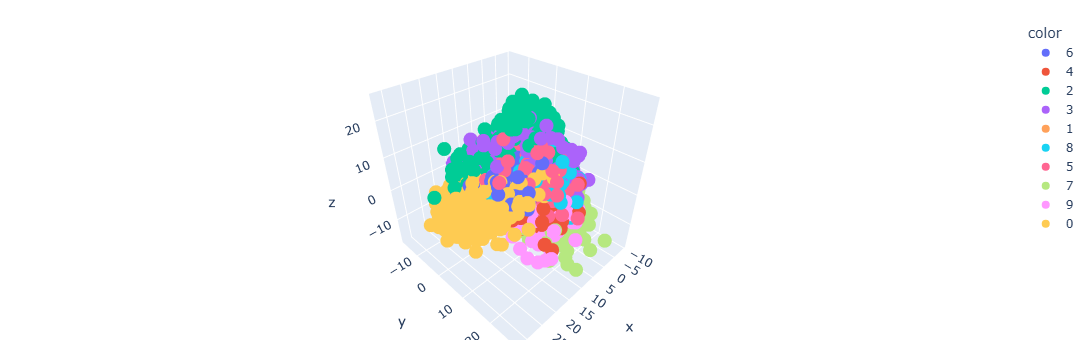

In [124]:
import plotly.express as px
fig=px.scatter_3d(x=x_train_trf[:,0],y=x_train_trf[:,1],z=x_train_trf[:,2],color=y_train.astype(str))
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)
fig.show()


- some methods

In [131]:
pc=PCA(n_components=None)
pc.fit(x_train)
x_train_trf=pc.transform(x_train)
x_test_trf=pc.transform(x_test)
pc.explained_variance_
# eigen values

array([4.06411512e+01, 2.92614085e+01, 2.66427739e+01, 2.08489471e+01,
       1.80353164e+01, 1.58229572e+01, 1.38833402e+01, 1.25322922e+01,
       1.11094997e+01, 1.00761683e+01, 9.65806617e+00, 8.67741469e+00,
       8.02409809e+00, 7.90593780e+00, 7.46582341e+00, 7.17590328e+00,
       6.73829966e+00, 6.60517454e+00, 6.46972095e+00, 6.29961932e+00,
       5.95011103e+00, 5.75939921e+00, 5.53553269e+00, 5.32416770e+00,
       5.16880291e+00, 4.96007351e+00, 4.91214540e+00, 4.75020518e+00,
       4.48960303e+00, 4.39091711e+00, 4.34249590e+00, 4.28186366e+00,
       4.13664252e+00, 4.05205011e+00, 4.02950164e+00, 3.91897235e+00,
       3.84354230e+00, 3.70430209e+00, 3.60008516e+00, 3.51652486e+00,
       3.44874653e+00, 3.41271949e+00, 3.29579002e+00, 3.27822512e+00,
       3.19342575e+00, 3.16830154e+00, 3.15185602e+00, 3.11978532e+00,
       3.04270804e+00, 2.98670852e+00, 2.88829184e+00, 2.86108966e+00,
       2.83037294e+00, 2.79165932e+00, 2.75849742e+00, 2.66572825e+00,
      

In [133]:
pc.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]], shape=(784, 784))

# finding optical number of principle components

In [146]:
from sklearn.model_selection import train_test_split
x=df.iloc[:,1:]
y=df.iloc[:,0]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [147]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
st.fit(x_train)
x_train=st.transform(x_train)
x_test=st.transform(x_test)

In [150]:
from sklearn.decomposition import PCA
pca=PCA(n_components=None)
pca.fit(x_train)
x_train_trf=pca.transform(x_train)
x_test_trf=pca.transform(x_test)

In [153]:
pca.explained_variance_
# eigen values

array([4.06411512e+01, 2.92614085e+01, 2.66427739e+01, 2.08489471e+01,
       1.80353164e+01, 1.58229572e+01, 1.38833402e+01, 1.25322922e+01,
       1.11094997e+01, 1.00761683e+01, 9.65806617e+00, 8.67741469e+00,
       8.02409809e+00, 7.90593780e+00, 7.46582341e+00, 7.17590328e+00,
       6.73829966e+00, 6.60517454e+00, 6.46972095e+00, 6.29961932e+00,
       5.95011103e+00, 5.75939921e+00, 5.53553269e+00, 5.32416770e+00,
       5.16880291e+00, 4.96007351e+00, 4.91214540e+00, 4.75020518e+00,
       4.48960303e+00, 4.39091711e+00, 4.34249590e+00, 4.28186366e+00,
       4.13664252e+00, 4.05205011e+00, 4.02950164e+00, 3.91897235e+00,
       3.84354230e+00, 3.70430209e+00, 3.60008516e+00, 3.51652486e+00,
       3.44874653e+00, 3.41271949e+00, 3.29579002e+00, 3.27822512e+00,
       3.19342575e+00, 3.16830154e+00, 3.15185602e+00, 3.11978532e+00,
       3.04270804e+00, 2.98670852e+00, 2.88829184e+00, 2.86108966e+00,
       2.83037294e+00, 2.79165932e+00, 2.75849742e+00, 2.66572825e+00,
      

In [155]:
pca.components_
#eigen vectors

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]], shape=(784, 784))

In [157]:
pca.explained_variance_ratio_
# this is the percentage that how many each eigen vector coverd the variance

array([5.83069464e-02, 4.19806853e-02, 3.82237890e-02, 2.99115159e-02,
       2.58748632e-02, 2.27008412e-02, 1.99181162e-02, 1.79797980e-02,
       1.59385496e-02, 1.44560523e-02, 1.38562105e-02, 1.24492919e-02,
       1.15119932e-02, 1.13424713e-02, 1.07110491e-02, 1.02951072e-02,
       9.66728711e-03, 9.47629549e-03, 9.28196326e-03, 9.03792228e-03,
       8.53649059e-03, 8.26288062e-03, 7.94170437e-03, 7.63846377e-03,
       7.41556539e-03, 7.11610601e-03, 7.04734462e-03, 6.81501263e-03,
       6.44113258e-03, 6.29955011e-03, 6.23008130e-03, 6.14309357e-03,
       5.93474807e-03, 5.81338525e-03, 5.78103546e-03, 5.62246157e-03,
       5.51424377e-03, 5.31447897e-03, 5.16496129e-03, 5.04507920e-03,
       4.94783916e-03, 4.89615197e-03, 4.72839588e-03, 4.70319591e-03,
       4.58153617e-03, 4.54549102e-03, 4.52189700e-03, 4.47588589e-03,
       4.36530486e-03, 4.28496360e-03, 4.14376740e-03, 4.10474105e-03,
       4.06067246e-03, 4.00513090e-03, 3.95755427e-03, 3.82446042e-03,
      

In [159]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05830695, 0.10028763, 0.13851142, 0.16842294, 0.1942978 ,
       0.21699864, 0.23691676, 0.25489656, 0.2708351 , 0.28529116,
       0.29914737, 0.31159666, 0.32310865, 0.33445112, 0.34516217,
       0.35545728, 0.36512457, 0.37460086, 0.38388283, 0.39292075,
       0.40145724, 0.40972012, 0.41766182, 0.42530029, 0.43271585,
       0.43983196, 0.4468793 , 0.45369432, 0.46013545, 0.466435  ,
       0.47266508, 0.47880817, 0.48474292, 0.49055631, 0.49633734,
       0.5019598 , 0.50747405, 0.51278853, 0.51795349, 0.52299857,
       0.52794641, 0.53284256, 0.53757095, 0.54227415, 0.54685569,
       0.55140118, 0.55592307, 0.56039896, 0.56476427, 0.56904923,
       0.573193  , 0.57729774, 0.58135841, 0.58536354, 0.5893211 ,
       0.59314556, 0.5969215 , 0.6006662 , 0.60430766, 0.60791184,
       0.61141996, 0.61491038, 0.61834564, 0.62177429, 0.6251811 ,
       0.62851747, 0.63182195, 0.63504067, 0.63824855, 0.64141191,
       0.64453498, 0.6476157 , 0.65067708, 0.65371506, 0.65673

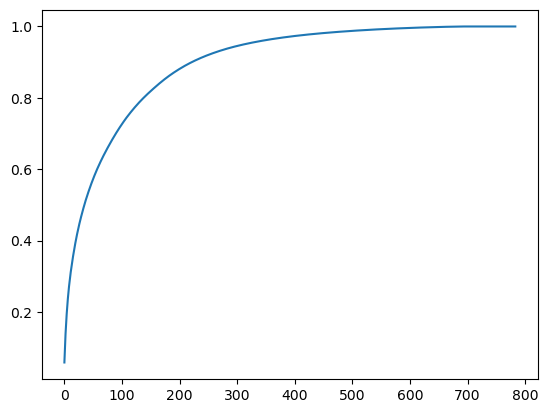

In [160]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [167]:
# so from above graph we can see that around 300 we get 90 percent of spred of data